<a href="https://colab.research.google.com/github/minjeon99/ESAA-10th-OB/blob/Week7/w7_fri_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **9. 추천시스템**

## **05 콘텐츠 기반 필터링 실습 - TMBD 5000 영화 데이터 세트**
- **TMBD 5000 영화 데이터 세트:** 영화 사이트 IMDB의 주요 5000개 영화에 대한 메타 정보를 가공한 데이터

### 장르 속성을 이용한 영화 콘텐츠 기반 필터링
콘텐츠 기반 필터링: 사용자가 특정 영화를 감상하고 그 영화를 좋아했다면, 그 영화와 비슷한 특성/속성, 구성 요소 등을 가진 다른 영화를 추천하는 것

  e.g. '인셉션'

  - (장르) 액션, 공상과학의 높은 평점을 가진 다른 영화
  - (감독) 크리스토퍼 놀란의 다른 영화

⏩ 장르 속성을 기반으로 콘텐츠 기반 필터링 추천 시스템을 만들어보기

### 데이터 로딩 및 가공

In [3]:
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')

movies = pd.read_csv('/content/tmdb_5000_movies.csv')
print(movies.shape)
movies.head()

(4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


- 4803개의 레코드, 20개의 피처
- 주요 칼럼만 추출해 DF 만들기

In [4]:
movies_df = movies[['id', 'title', 'genres', 'vote_average', 'vote_count', 'popularity', 'keywords', 'overview']]

⚠️ `genre`, `keywords` 칼럼
  - 리스트 내부에 여러 개의 딕셔너리가 있는 형태의 문자열로 표기
    - 한 영화가 여러 장르나 키워드로 구성될 수 있기 때문
  ➡️ 가공 필요

In [6]:
pd.set_option('max_colwidth', 100)
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""sp..."


- genres 칼럼의 문자열을 분해해서 개별 장르를 파이썬 리스트 객채로 추출
- `ast` 모듈의 `literal_eval()`를 이용하여 문자열이 의미하는 `list [ dict1, dict2 ]` 객체로 만들 수 있음

In [7]:
from ast import literal_eval
movies_df['genres'] = movies_df['genres'].apply(literal_eval)
movies_df['keywords'] = movies_df['keywords'].apply(literal_eval)

- 이제 genres 칼럼은 문자열이 아니라, 실제 리스트 내부에 여러 장르 딕셔너리로 구성된 객체를 가짐
- 장르명만 리스트 객체로 추출하기

In [8]:
movies_df['genres'] = movies_df['genres'].apply(lambda x: [y['name'] for y in x])
movies_df['keywords'] = movies_df['keywords'].apply(lambda x: [y['name'] for y in x])
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, spa..."


### 장르 콘텐츠 유사도 측정
- 여러 개의 개별 장르가 리스트로 구성되어 있는 genres 칼럼
- 장르별 유사도를 측정할 방법?
  - genres를 문자열로 변경한 뒤, CountVectorizer로 피처 벡터화한 행렬 데이터 값을 코사인 유사도로 비교하기
1. 문자열로 변환된 genres 칼럼을 Count 기반으로 피처 벡터화 변환
2. genres 문자열을 피처 벡터화 행렬로 변환한 데이터 세트를 코사인 유사도를 통해 비교
  - 이를 위해 데이터 세트의 레코드별로 타 레코드와 장르에서 코사인 유사도 값을 가지는 객체 생성
3. 장르 유사도가 높은 영화 중 평점이 높은 순으로 영화 추천

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# CountVectorizer를 적용하기 위해 공백문자로 word 단위가 구분되는 문자열로 변환
movies_df['genres_literal'] = movies_df['genres'].apply(lambda x: (' ').join(x))
count_vect = CountVectorizer(min_df=0.0, ngram_range=(1,2))
genre_mat = count_vect.fit_transform(movies_df['genres_literal'])
print(genre_mat.shape)

(4803, 276)


- 코사인 유사도 행렬 `cosine_similarity`

  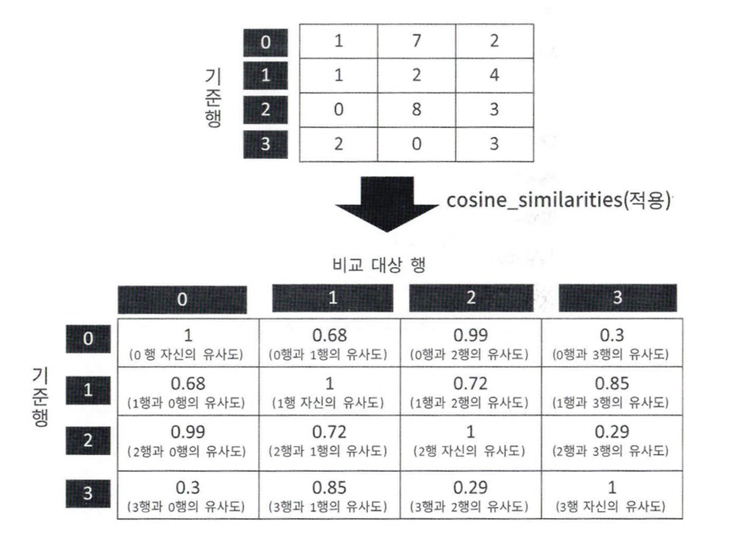

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

genre_sim = cosine_similarity(genre_mat, genre_mat)
print(genre_sim.shape)
print(genre_sim[:2])

(4803, 4803)
[[1.         0.59628479 0.4472136  ... 0.         0.         0.        ]
 [0.59628479 1.         0.4        ... 0.         0.         0.        ]]


- 장르 기준 콘텐츠 기반 필터링을 수행하려면 movies_df의 개별 레코드에 대해서 가장 장르 유사도가 높은 순으로 다른 레코드를 추출해야 함

In [12]:
genre_sim_sorted_ind = genre_sim.argsort()[:, ::-1]
print(genre_sim_sorted_ind[:1])

[[   0 3494  813 ... 3038 3037 2401]]


- 0번 레코드 예시
  - 자신(0) 제외
  - 3494 레코드: 가장 높은 유사도
  - 813 레코드: 그 다음으로 높은 유사도
  - 2401 레코드: 가장 낮은 유사도

### 장르 콘텐츠 필터링을 이용한 영화 추천
- `find_sim_movie()`: 장르 유사도에 따라 영화를 추천하는 함수 생성

In [13]:
def find_sim_movie(df, sorted_ind, title_name, top_n=10):
  # 인자로 입력된 movies_df DataFrame에서 'title' 칼럼이 입력된 title_name 값인 DataFrame 추출
  title_movie = df[df['title']==title_name]

  # title_name을 가진 DataFrame의 index 객체를 ndarray로 반환
  # sorted_ind 인자로 입력된 genre_sim_sorted_ind 객체에서 유사도 순으로 top_n개의 index 추출
  title_index = title_movie.index.values
  similar_indexes = sorted_ind[title_index, :(top_n)]

  # 추출된 top_n index 출력. top_n index: 2차원 데이터
  # dataframe에서 index로 사용하기 위해 1차원 array로 변경
  print(similar_indexes)
  similar_indexes = similar_indexes.reshape(-1)

  return df.iloc[similar_indexes]

In [14]:
similar_movies = find_sim_movie(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title', 'vote_average']]

[[2731 1243 3636 1946 2640 4065 1847 4217  883 3866]]


,title,vote_average
2731,The Godfather: Part II,8.3
1243,Mean Streets,7.2
3636,Light Sleeper,5.7
1946,The Bad Lieutenant: Port of Call - New Orleans,6.0
2640,Things to Do in Denver When You're Dead,6.7
4065,Mi America,0.0
1847,GoodFellas,8.2
4217,Kids,6.8
883,Catch Me If You Can,7.7
3866,City of God,8.1


- 대부 2편이 가장 먼저 추천됨
- 1847(좋은 친구들)도 대부와 비슷한 유형

  ↔️

- 반면, 낯선 영화도 많음
- 라이트 슬리퍼, Mi America, Kids 등 대부를 좋아하는 고객에게 섣불리 추천하기에는 이해하기 어려운 영화도 존재
  - 평점이 매우 낮은 경우도

⏩ 개선 필요
  - 더 많은 후보군 선정 → 평점에 따라 필터링 → 최종 추천하는 방식으로 변경

  - `vote_average`: 0~10까지의 점수, 여러 관객이 평가한 평점 평균

    ⚠️ 소수의 관객이 특정 영화에 만점이나 매우 높은 평점을 부여해 왜곡된 데이터를 가짐

In [15]:
movies_df[['title', 'vote_average', 'vote_count']].sort_values('vote_average', ascending=False)[:10]

,title,vote_average,vote_count
3519,Stiff Upper Lips,10.0,1
4247,Me You and Five Bucks,10.0,2
4045,"Dancer, Texas Pop. 81",10.0,1
4662,Little Big Top,10.0,1
3992,Sardaarji,9.5,2
2386,One Man's Hero,9.3,2
2970,There Goes My Baby,8.5,2
1881,The Shawshank Redemption,8.5,8205
2796,The Prisoner of Zenda,8.4,11
3337,The Godfather,8.4,5893


- 쇼생크 탈출, 대부 같은 명작보다 높은 순위에 이름도 들어본 적이 없는 영화가 더 높은 평점으로 존재
  - 평가 횟수가 매우 적음 => 왜곡된 평점을 회피하도록 새로운 평가 방식 필요
- 가중 평점(Weighted Rating) 이용
$$가중 \space 평점(Weighted Rating)=(v/(v+m)) * R + (m/(v+m)) * C$$
  - v: 개별 영화에 평점 투표한 횟수 = `vote_count`
  - m: 평점 부여를 위한 최소 투표 횟수
    - m을 높일수록, 평점 투표 횟수가 많은 영화에 더 많은 가중 평점 부여
    - 상위 60%에 해당하는 횟수 기준으로 설정
  - R: 개별 영화에 대한 평균 평점 = `vote_average`
  - C: 전체 영화에 대한 평균 평점 = `movies_df['vote_average'].mean()`

In [16]:
C = movies_df['vote_average'].mean()
m = movies_df['vote_count'].quantile(0.6)
print('C:', round(C,3), 'm:', round(m,3))

C: 6.092 m: 370.2


In [17]:
percentile = 0.6
m = movies_df['vote_count'].quantile(percentile)
C = movies_df['vote_average'].mean()

def weighted_vote_average(record):
  v = record['vote_count']
  R = record['vote_average']

  return ((v/(v+m))*R) + ((m/(m+v))*C)

movies_df['weighted_vote'] = movies.apply(weighted_vote_average, axis=1)

In [23]:
movies_df[['title', 'vote_average', 'weighted_vote', 'vote_count']].sort_values('weighted_vote', ascending=False)[:10]

,title,vote_average,weighted_vote,vote_count
1881,The Shawshank Redemption,8.5,8.396052,8205
3337,The Godfather,8.4,8.263591,5893
662,Fight Club,8.3,8.216455,9413
3232,Pulp Fiction,8.3,8.207102,8428
65,The Dark Knight,8.2,8.136930,12002
1818,Schindler's List,8.3,8.126069,4329
3865,Whiplash,8.3,8.123248,4254
809,Forrest Gump,8.2,8.105954,7927
2294,Spirited Away,8.3,8.105867,3840
2731,The Godfather: Part II,8.3,8.079586,3338


- 새롭게 정의된 평점 기준에 따라서 영화 추천

In [24]:
def find_sim_movie(df, sorted_ind, title_name, top_n=10):
  title_movie = df[df['title']==title_name]
  title_index = title_movie.index.values

  # top_n의 2배에 해당하는 장르 유사성이 높은 인덱스 추출
  similar_indexes = sorted_ind[title_index, :(top_n*2)]
  similar_indexes = similar_indexes.reshape(-1)
  # 기준 영화 인덱스 제외
  similar_indexes = similar_indexes[similar_indexes != title_index]

  # top_n의 2배에 해당하는 후보군에서 weighted_vote가 높은 순으로 top_n만큼 추출
  return df.iloc[similar_indexes].sort_values('weighted_vote', ascending=False)[:top_n]

similar_movies = find_sim_movie(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title', 'vote_average', 'weighted_vote']]

,title,vote_average,weighted_vote
2731,The Godfather: Part II,8.3,8.079586
1847,GoodFellas,8.2,7.976937
3866,City of God,8.1,7.759693
1663,Once Upon a Time in America,8.2,7.657811
883,Catch Me If You Can,7.7,7.557097
281,American Gangster,7.4,7.141396
4041,This Is England,7.4,6.739664
1149,American Hustle,6.8,6.717525
1243,Mean Streets,7.2,6.626569
2839,Rounders,6.9,6.530427


- 이전에 추천된 영화보다 더 나은 추천